# Customer Experience Analysis — Steps

1. Import libraries
2. Load dataset
3. Inspect data
4. Filter to target airline
5. Exploratory Data Analysis (distributions, plots)
6. Remove unwanted columns
7. Handle missing values
8. Date processing & feature extraction
9. Prepare features and target
10. Split data
11. Train XGBoost classifier
12. Evaluate model
13. Classification report


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## 1 — Import libraries

Import `pandas`, `numpy`, and plotting libraries for analysis.


In [32]:
df= pd.read_excel('Skytrax Airline Review Data.xlsx')

## 2 — Load dataset

Read the Skytrax reviews Excel file into `df`.


In [33]:
df.head()

,review_date,over_all_rating,review_header,trip_verified,review_text,aircraft,type_of_traveller,seat_type,route,date_flown,seat_comfort,cabin_staff_service,food__beverages,inflight_entertainment,ground_service,wifi__connectivity,value_for_money,recommended,airline_name
0,2025-08-04,1.0,"""showed zero empathy for passengers""",Trip Verified,My afternoon flight was delayed and eventuall...,NaN,business,economy_class,dubai_to_kochi,august_2025,1.0,2.0,2.0,2.0,1.0,1.0,1.0,no,spicejet
1,2025-07-21,2.0,"""Extremely dissatisfied""",Trip Verified,The flight was postponed 3 times with insuffi...,NaN,family_leisure,economy_class,pune_to_dubai,july_2025,1.0,3.0,NaN,NaN,3.0,NaN,2.0,no,spicejet
2,2025-04-19,2.0,"""Very bad experience""",Trip Verified,They will charge you for your hand baggage if...,NaN,business,economy_class,mumbai_to_kolkata,april_2025,3.0,3.0,3.0,NaN,1.0,NaN,2.0,no,spicejet
3,2025-03-12,1.0,“What a difficult airline”,Trip Verified,The flight was delayed from 15:20 to 16:25. I...,NaN,business,economy_class,"pune,_india_to_new_delhi,_india",march_2025,3.0,4.0,NaN,NaN,5.0,NaN,1.0,no,spicejet
4,2025-03-02,2.0,“Poor chaotic boarding”,Trip Verified,No crowd control and boarding was like cattle...,boeing_747,solo_leisure,economy_class,mumbai_to_new_delhi,march_2025,3.0,1.0,3.0,NaN,1.0,NaN,2.0,no,spicejet


## 3 — Inspect data

Preview the top rows to understand columns and sample values.


In [34]:
# selecting rows where airline_name is Virgin Australia
df=df[df['airline_name'] == 'virgin-australia']

## 4 — Filter to target airline

Keep only rows for Virgin Australia for focused analysis.


In [35]:
df.head()


,review_date,over_all_rating,review_header,trip_verified,review_text,aircraft,type_of_traveller,seat_type,route,date_flown,seat_comfort,cabin_staff_service,food__beverages,inflight_entertainment,ground_service,wifi__connectivity,value_for_money,recommended,airline_name
8080,2025-08-05,5.0,"""At least they got us there""",Trip Verified,Unfortunately the plane was delayed. Then we ...,NaN,solo_leisure,economy_class,brisbane_to_townsville,july_2025,3.0,3.0,3.0,NaN,3.0,NaN,3.0,yes,virgin-australia
8081,2025-08-05,7.0,"""an enjoyable experience""",Trip Verified,The staff were friendly and helpful and the p...,boeing_737_800,solo_leisure,economy_class,melbourne_to_brisbane,july_2025,3.0,4.0,3.0,NaN,4.0,NaN,3.0,yes,virgin-australia
8082,2025-07-22,8.0,"""not worth the extra in cost""",Trip Verified,However no divider on this plane plus the pro...,NaN,couple_leisure,economy_class,melbourne_to_brisbane,june_2025,4.0,3.0,NaN,NaN,4.0,NaN,2.0,yes,virgin-australia
8083,2025-07-02,4.0,"""Virgin Australia is inconsistent""",Not Verified,"Sometimes, the staff are pleasant and friendl...",boeing_737,business,business_class,gold_coast_to_sydney,july_2025,2.0,2.0,1.0,2.0,2.0,2.0,3.0,no,virgin-australia
8084,2025-06-18,6.0,"""staff were friendly""",Trip Verified,Aside from this it was an enjoyable flight. T...,boeing_737-800,solo_leisure,economy_class,melbourne_to_sydney,june_2025,3.0,4.0,3.0,NaN,4.0,NaN,3.0,yes,virgin-australia


In [36]:
df.recommended.value_counts()

recommended
no     397
yes    333
Name: count, dtype: int64

## 5 — EDA: distributions

Plot and inspect distributions for `recommended` and `over_all_rating`.


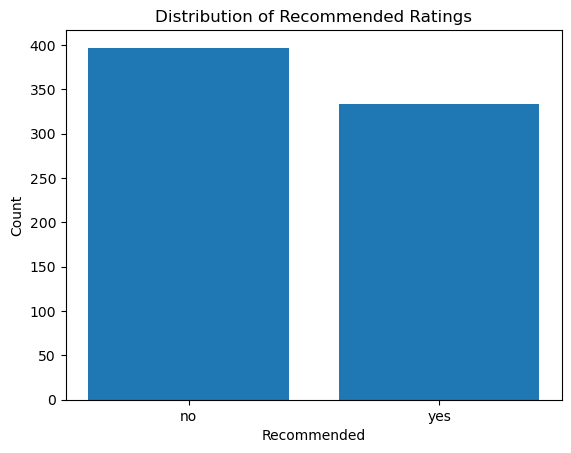

In [37]:
plt.bar(df.recommended.value_counts().index, df.recommended.value_counts().values)
plt.xlabel('Recommended')
plt.ylabel('Count')
plt.title('Distribution of Recommended Ratings')
plt.show()

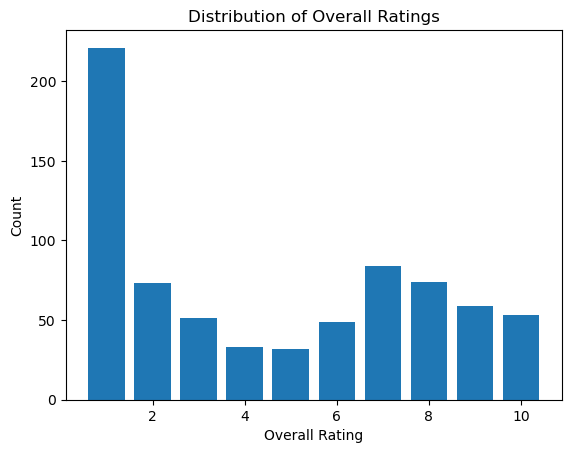

In [38]:
# lets plot rating average
plt.bar(df['over_all_rating'].value_counts().index, df['over_all_rating'].value_counts().values)
plt.xlabel('Overall Rating')
plt.ylabel('Count')
plt.title('Distribution of Overall Ratings')
plt.show()

In [39]:
df.isnull().sum()

review_date                 0
over_all_rating             1
review_header               0
trip_verified             122
review_text                 2
aircraft                  369
type_of_traveller          35
seat_type                   0
route                      38
date_flown                 38
seat_comfort               30
cabin_staff_service        30
food__beverages           134
inflight_entertainment    318
ground_service             50
wifi__connectivity        469
value_for_money             0
recommended                 0
airline_name                0
dtype: int64

In [40]:
# lets remove unwanterd columns like trip_verified, review text and review header(as we need NLP for this), aircraft, route
df = df.iloc[:, [0, 1, 6, 7] + list(range(9, df.shape[1]-1))]

## 6 — Remove unwanted columns

Drop text-heavy or irrelevant columns (e.g., review text) for this analysis.


In [41]:
df.head()

,review_date,over_all_rating,type_of_traveller,seat_type,date_flown,seat_comfort,cabin_staff_service,food__beverages,inflight_entertainment,ground_service,wifi__connectivity,value_for_money,recommended
8080,2025-08-05,5.0,solo_leisure,economy_class,july_2025,3.0,3.0,3.0,NaN,3.0,NaN,3.0,yes
8081,2025-08-05,7.0,solo_leisure,economy_class,july_2025,3.0,4.0,3.0,NaN,4.0,NaN,3.0,yes
8082,2025-07-22,8.0,couple_leisure,economy_class,june_2025,4.0,3.0,NaN,NaN,4.0,NaN,2.0,yes
8083,2025-07-02,4.0,business,business_class,july_2025,2.0,2.0,1.0,2.0,2.0,2.0,3.0,no
8084,2025-06-18,6.0,solo_leisure,economy_class,june_2025,3.0,4.0,3.0,NaN,4.0,NaN,3.0,yes


In [42]:
df.iloc[[0][0]]

review_date                  2025-08-05
over_all_rating                     5.0
type_of_traveller          solo_leisure
seat_type                 economy_class
date_flown                    july_2025
seat_comfort                        3.0
cabin_staff_service                 3.0
food__beverages                     3.0
inflight_entertainment              NaN
ground_service                      3.0
wifi__connectivity                  NaN
value_for_money                     3.0
recommended                         yes
Name: 8080, dtype: object

In [43]:
df.isnull().sum()

review_date                 0
over_all_rating             1
type_of_traveller          35
seat_type                   0
date_flown                 38
seat_comfort               30
cabin_staff_service        30
food__beverages           134
inflight_entertainment    318
ground_service             50
wifi__connectivity        469
value_for_money             0
recommended                 0
dtype: int64

In [44]:
# mean is used in over_all_rating,and all other individual rating

for i in [1,5,6, 7, 8, 9, 10]:
    mean = df.iloc[:, i].mean()
    df.iloc[:, i] = df.iloc[:, i].fillna(mean)

## 7 — Handle missing values

Fill missing numeric ratings with column means to retain rows.


In [45]:
df.isnull().sum()

review_date                0
over_all_rating            0
type_of_traveller         35
seat_type                  0
date_flown                38
seat_comfort               0
cabin_staff_service        0
food__beverages            0
inflight_entertainment     0
ground_service             0
wifi__connectivity         0
value_for_money            0
recommended                0
dtype: int64

In [46]:
df.isnull().sum()

review_date                0
over_all_rating            0
type_of_traveller         35
seat_type                  0
date_flown                38
seat_comfort               0
cabin_staff_service        0
food__beverages            0
inflight_entertainment     0
ground_service             0
wifi__connectivity         0
value_for_money            0
recommended                0
dtype: int64

In [47]:
len(df)

730

In [48]:
df['type_of_traveller'] = df['type_of_traveller'].fillna(
    df['type_of_traveller'].mode()[0]
)

df['date_flown'] = df['date_flown'].fillna(
    df['date_flown'].mode()[0]
)

## 8 — Fill categorical/date missing values

Impute mode for categorical dates and traveller type before conversion.


In [49]:
df.isnull().sum()

review_date               0
over_all_rating           0
type_of_traveller         0
seat_type                 0
date_flown                0
seat_comfort              0
cabin_staff_service       0
food__beverages           0
inflight_entertainment    0
ground_service            0
wifi__connectivity        0
value_for_money           0
recommended               0
dtype: int64

In [50]:
df['date_flown'] = pd.to_datetime(
    df['date_flown'],
    format='%B_%Y',
    errors='coerce'
)

## 9 — Convert dates

Convert `date_flown` to datetime to enable year/month extraction.


In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 730 entries, 8080 to 8809
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   review_date             730 non-null    str           
 1   over_all_rating         730 non-null    float64       
 2   type_of_traveller       730 non-null    str           
 3   seat_type               730 non-null    str           
 4   date_flown              730 non-null    datetime64[us]
 5   seat_comfort            730 non-null    float64       
 6   cabin_staff_service     730 non-null    float64       
 7   food__beverages         730 non-null    float64       
 8   inflight_entertainment  730 non-null    float64       
 9   ground_service          730 non-null    float64       
 10  wifi__connectivity      730 non-null    float64       
 11  value_for_money         730 non-null    float64       
 12  recommended             730 non-null    str           
dt

In [52]:
# Now that we cleaned lets use ML Classification XGBoost to train a model
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [53]:
# Target
y = df['recommended'].replace({'yes': 1, 'no': 0})
y = y.astype(int)

# Features
X = df.drop(columns=['recommended', 'over_all_rating'])

# Convert review_date to datetime
X['review_date'] = pd.to_datetime(X['review_date'], errors='coerce')

# Extract useful date information
X['review_year'] = X['review_date'].dt.year
X['review_month'] = X['review_date'].dt.month

X['flight_year'] = X['date_flown'].dt.year
X['flight_month'] = X['date_flown'].dt.month

# Remove original date columns
X = X.drop(['review_date', 'date_flown'], axis=1)

# Convert categorical columns
X['type_of_traveller'] = X['type_of_traveller'].astype('category')
X['seat_type'] = X['seat_type'].astype('category')


## 10 — Prepare features & target

Create `X` and `y`, extract date features, and cast categoricals.


In [54]:
y.unique()

array([1, 0])

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

## 11 — Split data

Split into training and test sets (`test_size=0.2`).


In [56]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.09,
    tree_method='hist',
    enable_categorical=True,
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

## 12 — Train XGBoost classifier

Instantiate and fit an `XGBClassifier` with chosen hyperparameters.


In [57]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9657534246575342


## 13 — Evaluate model

Predict on `X_test` and compute accuracy.


In [58]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.97        78
           1       0.97      0.96      0.96        68

    accuracy                           0.97       146
   macro avg       0.97      0.97      0.97       146
weighted avg       0.97      0.97      0.97       146



## 14 — Classification report

Print precision, recall, and f1-score for each class.


In [59]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                   Feature  Importance
8          value_for_money    0.571647
3      cabin_staff_service    0.108477
6           ground_service    0.050685
5   inflight_entertainment    0.038185
1                seat_type    0.038182
4          food__beverages    0.034335
7       wifi__connectivity    0.033579
0        type_of_traveller    0.026474
2             seat_comfort    0.022162
11             flight_year    0.020946
10            review_month    0.020771
9              review_year    0.019919
12            flight_month    0.014637
